# Functional Data Analysis — Eurozone 10Y Government Bond Yield Changes


## 0. Install dependencies

In [1]:
# Run once if needed to install dependencies
!pip install rpy2 pyreadr scikit-fda ruptures statsmodels matplotlib numpy scipy pandas

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------  2.4/2.4 MB 21.1 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 17.9 MB/s  0:00:00
   ---------------------------------------- 0.0/577.2 kB ? eta -:--:--
   ---------------------------------------- 577.2/577.2 kB 17.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 24.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 20.9 MB/s  0:00:00

   -- -------------------------------------  1/15 [Cython]
   -- -------------------------------------  1/15 [Cython]
   -- -------------------------------------  1/15 [Cython]
   -- -------------------------------------  1/15 [Cython]
   -- -------------------------------------  1/15 [Cython]
   -- -------------------------------------  1/15


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Data


In [1]:
import pandas as pd
import numpy as np

orig_df = pd.read_csv("Eurozone_10Y_Yields_Monthly.csv")
orig_df["Date"] = pd.to_datetime(orig_df["Date"])

yields_matrix_df = pd.read_csv("yields_matrix.csv", index_col=0)
yields_matrix    = yields_matrix_df.values          # numpy array (59, n_curves)
countries        = list(yields_matrix_df.columns)   # country names
tt               = np.array(yields_matrix_df.index, dtype=float)

# Basis metadata
basis_info = pd.read_csv("basis_info.csv")
t_range    = [basis_info["t_min"][0], basis_info["t_max"][0]]

# Raw coefficients
coefs = pd.read_csv("yields_coefs.csv").values

print(f"yields_matrix : {yields_matrix.shape}")
print(f"countries     : {countries}")
print(f"t_range       : {t_range}")

yields_matrix : (59, 16)
countries     : ['Austria', 'Belgium', 'Cyprus', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Malta', 'Netherlands', 'Portugal', 'Slovakia']
t_range       : [np.int64(1), np.int64(59)]


## 2. Imports & Helper Functions

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (11, 4)

from scipy import stats
from scipy.interpolate import BSpline
from sklearn.decomposition import PCA
from collections import Counter

tt = np.arange(1, 60)    


## 3. Plot All Curves with Mean and SD

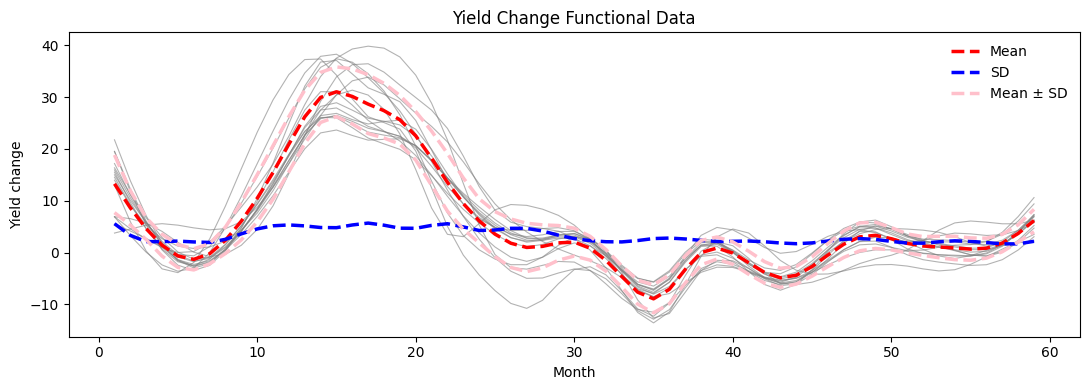

In [3]:
mean_vals = yields_matrix.mean(axis=1)
sd_vals   = yields_matrix.std(axis=1, ddof=1)

fig, ax = plt.subplots()
for j in range(yields_matrix.shape[1]):
    ax.plot(tt, yields_matrix[:, j], color="grey", lw=0.8, alpha=0.6)

ax.plot(tt, mean_vals,           color="red",  lw=2.5, ls="--", label="Mean")
ax.plot(tt, sd_vals,             color="blue", lw=2.5, ls="--", label="SD")
ax.plot(tt, mean_vals - sd_vals, color="pink", lw=2.5, ls="--", label="Mean ± SD")
ax.plot(tt, mean_vals + sd_vals, color="pink", lw=2.5, ls="--")
ax.set_xlabel("Month"); ax.set_ylabel("Yield change")
ax.set_title("Yield Change Functional Data")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 4. Bivariate Covariance Function

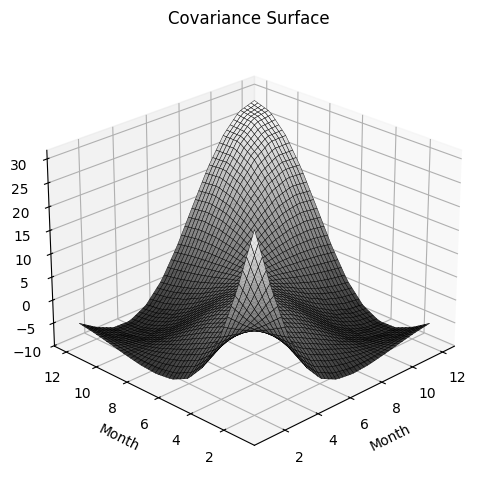

In [4]:
monthtime = np.linspace(1, 12, 50)


ym_cov = np.array([
    np.interp(monthtime, tt, yields_matrix[:, j])
    for j in range(yields_matrix.shape[1])
]).T                                 

yields_fd_mat = np.cov(ym_cov)

X, Y = np.meshgrid(monthtime, monthtime)

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, yields_fd_mat, cmap='gray', edgecolor='black', linewidth=0.3, alpha=0.8)

ax.view_init(elev=25, azim=45)          
ax.invert_xaxis()
ax.invert_yaxis()                     

ax.set_xlabel("Month")
ax.set_ylabel("Month")        
ax.set_zlabel("Covariance")
ax.set_title("Covariance Surface")

ticks = np.arange(2, 13, 2)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

plt.tight_layout()
plt.show()

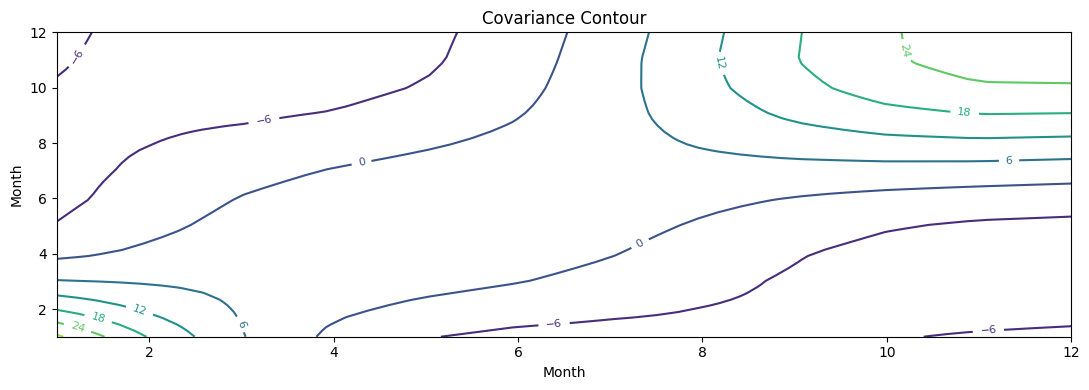

In [5]:
# Contour plot
fig, ax = plt.subplots()
cs = ax.contour(monthtime, monthtime, yields_fd_mat)
ax.clabel(cs, inline=True, fontsize=8)
ax.set_xlabel("Month"); ax.set_ylabel("Month")
ax.set_title("Covariance Contour")
plt.tight_layout(); plt.show()

## 5. Functional PCA

C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\666689219.py:9: DeprecationWarning: The BSpline class is deprecated. Use BSplineBasis instead.
  basis = BSpline(domain_range=(t_range[0], t_range[1]), n_basis=n_basis)
C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\666689219.py:25: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  mean_vals = yields_fd.mean().evaluate(monthtime)[0, :, 0]
C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\666689219.py:28: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  harmonic_vals = fpca.components_.evaluate(monthtime)[i, :, 0]


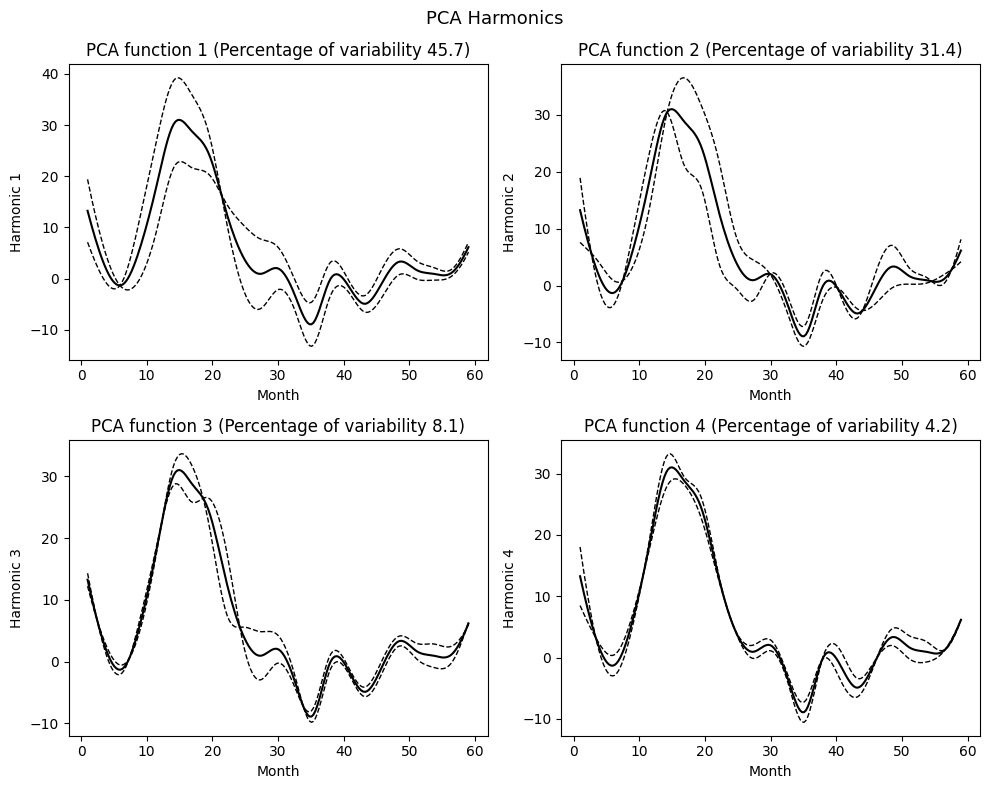

C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\666689219.py:51: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  harmonic_vals = fpca.components_.evaluate(monthtime)[i, :, 0] * sign_flip[i]


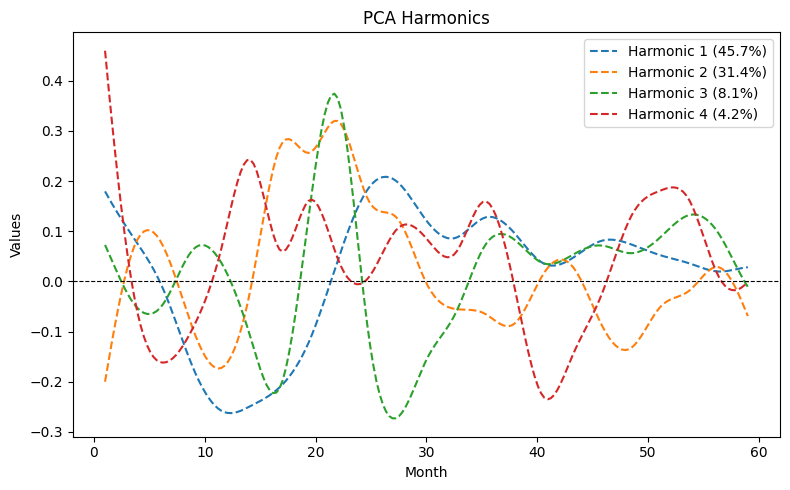

In [6]:
from skfda import FDataBasis
from skfda.representation.basis import BSpline
from skfda.preprocessing.dim_reduction import FPCA
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct yields_fd from saved data
n_basis = coefs.shape[0]
basis = BSpline(domain_range=(t_range[0], t_range[1]), n_basis=n_basis)
yields_fd = FDataBasis(basis=basis, coefficients=coefs.T)

nharm = 4
fpca = FPCA(n_components=nharm)
fpca.fit(yields_fd)

monthtime = np.linspace(t_range[0], t_range[1], 200)

# Figure 1
scores = fpca.transform(yields_fd)
std_scores = scores.std(axis=0) 

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

mean_vals = yields_fd.mean().evaluate(monthtime)[0, :, 0]

for i in range(nharm):
    harmonic_vals = fpca.components_.evaluate(monthtime)[i, :, 0]

    upper = mean_vals + 2 * std_scores[i] * harmonic_vals
    lower = mean_vals - 2 * std_scores[i] * harmonic_vals

    axes[i].plot(monthtime, mean_vals, color='black', linewidth=1.5)          # mean
    axes[i].plot(monthtime, upper,     color='black', linewidth=1, linestyle='--')  # +2SD
    axes[i].plot(monthtime, lower,     color='black', linewidth=1, linestyle='--')  # -2SD
    axes[i].set_title(f"PCA function {i+1} (Percentage of variability {fpca.explained_variance_ratio_[i]*100:.1f})")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel(f"Harmonic {i+1}")

plt.suptitle("PCA Harmonics", fontsize=13)
plt.tight_layout()
plt.show()

# Figure 2
# Flip harmonics 1 and 4 to match R's sign convention
sign_flip = [-1, 1, 1, -1]

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(nharm):
    harmonic_vals = fpca.components_.evaluate(monthtime)[i, :, 0] * sign_flip[i]
    ax.plot(monthtime, harmonic_vals, linestyle='--',
            label=f"Harmonic {i+1} ({fpca.explained_variance_ratio_[i]*100:.1f}%)")

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("Month")
ax.set_ylabel("Values")
ax.set_title("PCA Harmonics")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\368042266.py:5: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  mean_vals = yields_fd.mean().evaluate(monthtime)[0, :, 0]
C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\368042266.py:7: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  phi    = fpca.components_.evaluate(monthtime)[i, :, 0] * sign_flip[i]


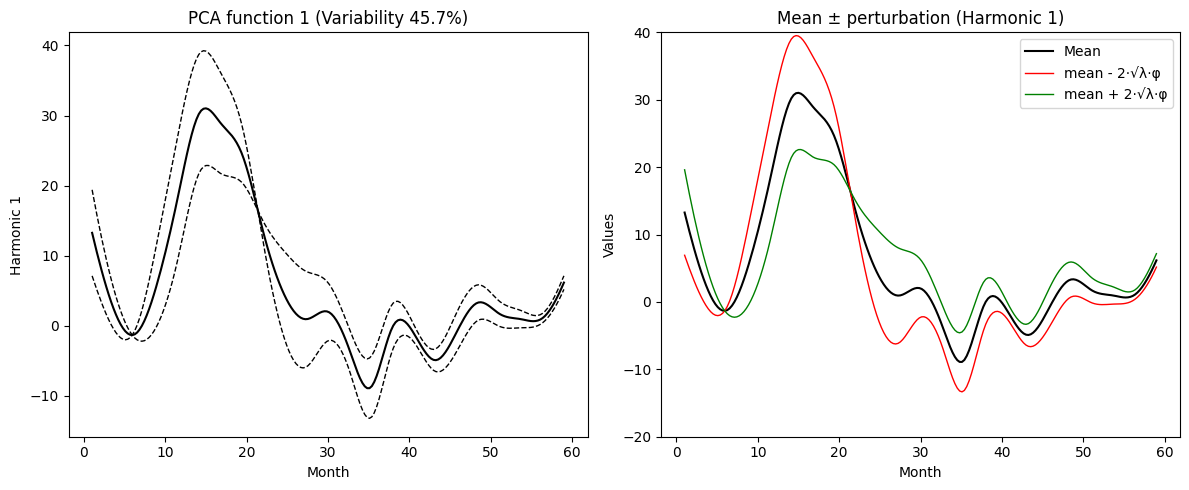

In [7]:
# PCA graphs explained: PC1 effect on mean
c_val = 2
i = 0  # harmonic 1 (0-indexed)

mean_vals = yields_fd.mean().evaluate(monthtime)[0, :, 0]

phi    = fpca.components_.evaluate(monthtime)[i, :, 0] * sign_flip[i]
lambda_ = fpca.explained_variance_[i]

f1 = mean_vals - c_val * np.sqrt(lambda_) * phi
f2 = mean_vals + c_val * np.sqrt(lambda_) * phi

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

std_scores = fpca.transform(yields_fd).std(axis=0)
upper = mean_vals + 2 * std_scores[i] * phi
lower = mean_vals - 2 * std_scores[i] * phi

axes[0].plot(monthtime, mean_vals, color='black', linewidth=1.5)
axes[0].plot(monthtime, upper, color='black', linewidth=1, linestyle='--')
axes[0].plot(monthtime, lower, color='black', linewidth=1, linestyle='--')
axes[0].set_title(f"PCA function 1 (Variability {fpca.explained_variance_ratio_[i]*100:.1f}%)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Harmonic 1")

axes[1].plot(monthtime, mean_vals, color='black', linewidth=1.5, label='Mean')
axes[1].plot(monthtime, f1, color='red',   linewidth=1, label=f'mean - {c_val}·√λ·φ')
axes[1].plot(monthtime, f2, color='green', linewidth=1, label=f'mean + {c_val}·√λ·φ')
axes[1].set_ylim(-20, 40)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Values")
axes[1].set_title("Mean ± perturbation (Harmonic 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
scores = fpca.transform(yields_fd)
# apply same sign flips as before
sign_flip = [-1, 1, 1, -1]
scores_flipped = scores * sign_flip 

mean_vals = yields_fd.mean().evaluate(monthtime)[0, :, 0]

# pre-evaluate all harmonics (with sign flip)
harmonics = [
    fpca.components_.evaluate(monthtime)[i, :, 0] * sign_flip[i]
    for i in range(nharm)
]

fd_pca1_list = []
fd_pca2_list = []
fd_pca3_list = []
fd_pca4_list = []

for i in range(5):
    fd_pca1_list.append(mean_vals + scores_flipped[i,0]*harmonics[0])

    fd_pca2_list.append(mean_vals + scores_flipped[i,0]*harmonics[0]
                                  + scores_flipped[i,1]*harmonics[1])

    fd_pca3_list.append(mean_vals + scores_flipped[i,0]*harmonics[0]
                                  + scores_flipped[i,1]*harmonics[1]
                                  + scores_flipped[i,2]*harmonics[2])

    fd_pca4_list.append(mean_vals + scores_flipped[i,0]*harmonics[0]
                                  + scores_flipped[i,1]*harmonics[1]
                                  + scores_flipped[i,2]*harmonics[2]
                                  + scores_flipped[i,3]*harmonics[3])

C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\4020749174.py:6: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  mean_vals = yields_fd.mean().evaluate(monthtime)[0, :, 0]
C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\4020749174.py:10: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  fpca.components_.evaluate(monthtime)[i, :, 0] * sign_flip[i]


## 6. Varimax Rotation - nesigauna (gaunasi kitokie rezultatai nei su R)

In [ ]:
šita kodo dalis "neišversta"


R kodas:

#### Rotation
opar <- par(mfrow=c(2,2))
varmx <- varmx.pca.fd(pcalist)
plot(varmx)
par(opar)

plot(varmx$harmonics)

plotscores(varmx, loc = 5)


# PCA restore the original curves
fd.vrm1.list <- list() 
fd.vrm2.list <- list() 
fd.vrm3.list <- list() 
fd.vrm4.list <- list() 

for(i in 1:5) {
  fd.vrm1.list[[i]] <- mean.fd(yields_fd) + 
    varmx$scores[i,1]*varmx$harmonics[1]
  
  fd.vrm2.list[[i]] <- mean.fd(yields_fd) +
    varmx$scores[i,1]*varmx$harmonics[1] + 
    varmx$scores[i,2]*varmx$harmonics[2]
  
  fd.vrm3.list[[i]]<- mean.fd(yields_fd) +
    varmx$scores[i,1]*varmx$harmonics[1] + 
    varmx$scores[i,2]*varmx$harmonics[2] +
    varmx$scores[i,3]*varmx$harmonics[3] 
  
  fd.vrm4.list[[i]]<- mean.fd(yields_fd) +
    varmx$scores[i,1]*varmx$harmonics[1] + 
    varmx$scores[i,2]*varmx$harmonics[2] +
    varmx$scores[i,3]*varmx$harmonics[3] +
    varmx$scores[i,4]*varmx$harmonics[4]
}

opar <- par(mfrow=c(2,2), ask = TRUE)
for(i in 1:5) {
  plot(fd.vrm1.list[[i]], ylim=c(-20, 40), ylab = "1 PC")
  lines(yields_fd[i], col = 2)
  
  plot(fd.vrm2.list[[i]], ylim=c(-20, 40), ylab = "2 PC")
  lines(yields_fd[i], col = 2)
  
  plot(fd.vrm3.list[[i]], ylim=c(-20, 40), ylab = "3 PC")
  lines(yields_fd[i], col = 2)
  
  plot(fd.vrm4.list[[i]], ylim=c(-20, 40), ylab = "4 PC")
  lines(yields_fd[i], col = 2)
}
par(opar)


## 7. Functional Depth, Boxplots and Outliers

In [9]:
dates  = pd.to_datetime(orig_df["Date"])
n_curves = yields_matrix.shape[1]
trim_k   = max(1, int(0.1 * n_curves))
tick_pos = np.arange(0, 59, 6)

def plot_depth(median_curve, mtrim_curve, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    for j in range(n_curves):
        ax.plot(tt, yields_matrix[:, j], color="grey", lw=0.8, alpha=0.6)
    ax.plot(tt, median_curve, color="red",  lw=2.5,       label="Median curve")
    ax.plot(tt, mtrim_curve,  color="blue", lw=2.5, ls="--", label="Trimmed mean (10%)")
    ax.set_xticks(tt[tick_pos])
    ax.set_xticklabels([dates.iloc[i].strftime("%Y-%m") for i in tick_pos],
                       rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Month"); ax.set_ylabel("Yield change")
    ax.set_title(title); ax.legend(frameon=False)
    plt.tight_layout(); plt.show()

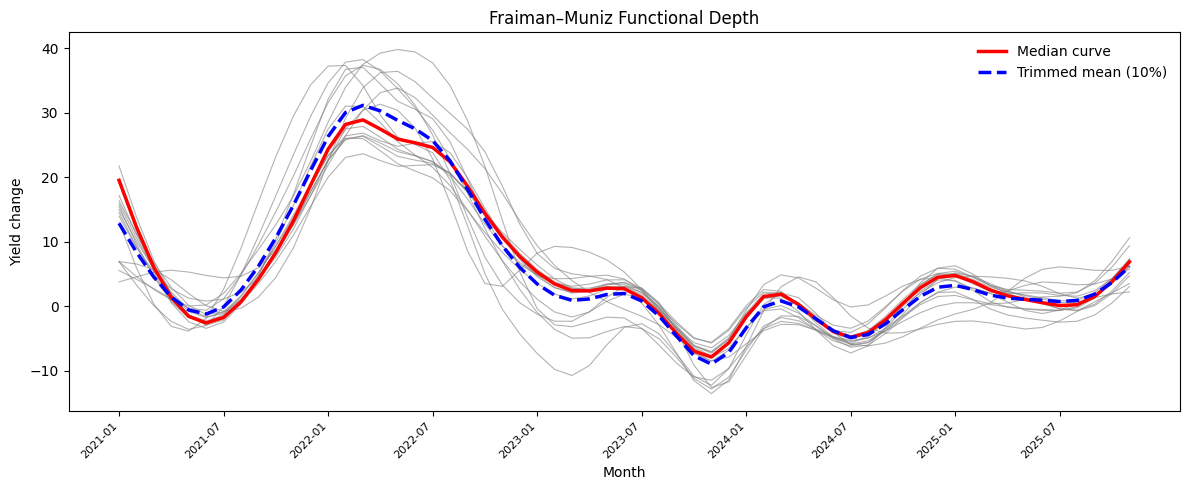

In [10]:
# Fraiman-Muniz depth
def fm_depth(data):
    n_t, n = data.shape
    depths = np.zeros(n)
    for t in range(n_t):
        col   = data[t, :]
        ranks = stats.rankdata(col)
        F_t   = ranks / n
        depths += 1 - np.abs(F_t - 0.5) * 2
    return depths / n_t

fm_depths   = fm_depth(yields_matrix)
median_idx  = np.argmax(fm_depths)
trim_idx    = np.argsort(fm_depths)[::-1][trim_k:]

plot_depth(
    yields_matrix[:, median_idx],
    yields_matrix[:, trim_idx].mean(axis=1),
    "Fraiman–Muniz Functional Depth"
)

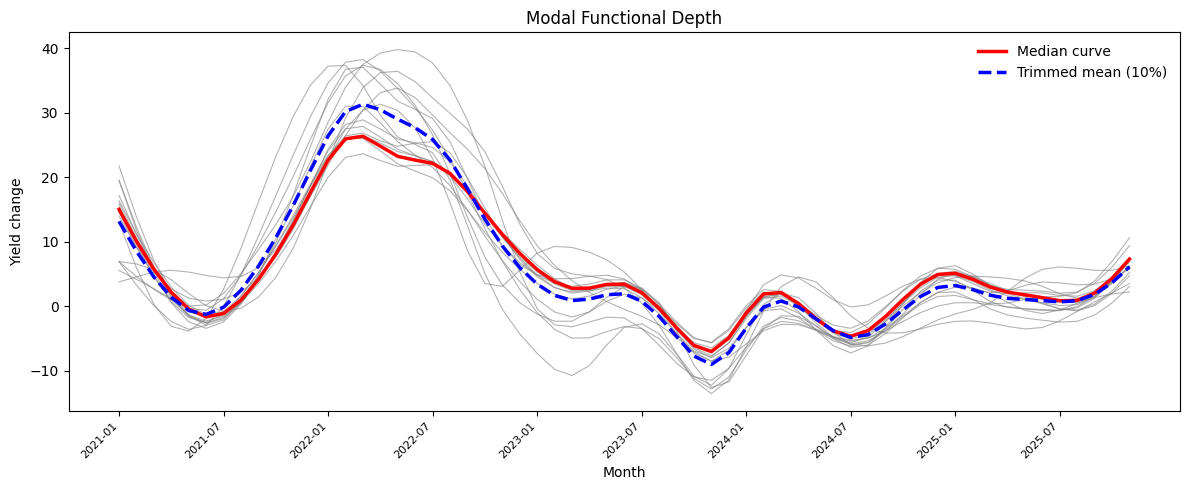

In [11]:
# Modal depth
def modal_depth(data, h=None):
    n_t, n = data.shape
    if h is None:
        h = np.std(data) * (n ** (-1/5))
    depths = np.zeros(n)
    for i in range(n):
        for j in range(n):
            diff = data[:, i] - data[:, j]
            depths[i] += np.exp(-0.5 * np.dot(diff, diff) / h**2)
    return depths / n

mode_depths      = modal_depth(yields_matrix)
median_mode_idx  = np.argmax(mode_depths)
trim_mode_idx    = np.argsort(mode_depths)[::-1][trim_k:]

plot_depth(
    yields_matrix[:, median_mode_idx],
    yields_matrix[:, trim_mode_idx].mean(axis=1),
    "Modal Functional Depth"
)

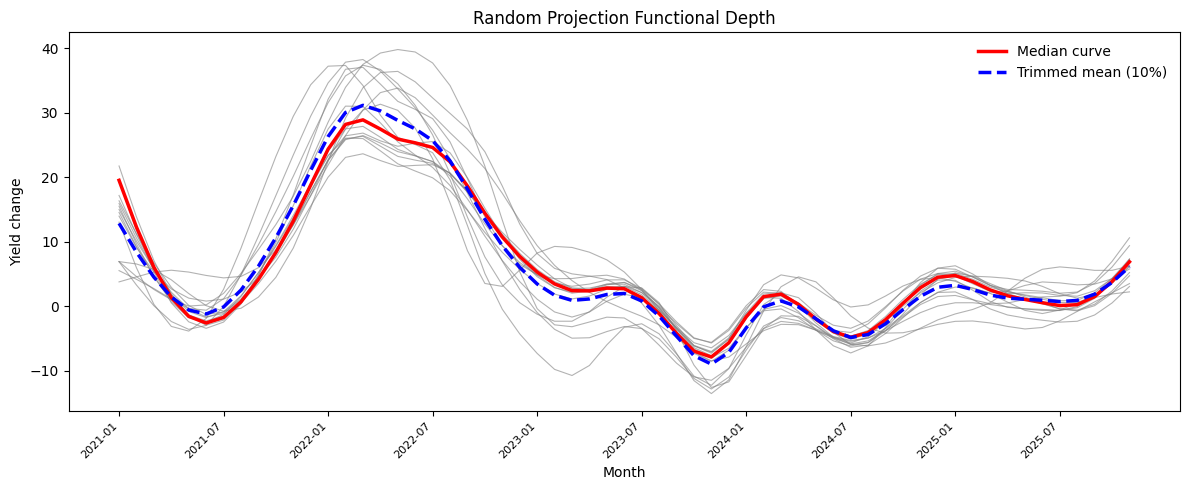

In [12]:
# Random Projection depth
def rp_depth(data, n_proj=200, seed=42):
    rng = np.random.default_rng(seed)
    n_t, n = data.shape
    depths = np.zeros(n)
    for _ in range(n_proj):
        v    = rng.normal(size=n_t)
        v   /= np.linalg.norm(v)
        proj = data.T @ v
        F_p  = stats.rankdata(proj) / n
        depths += 1 - np.abs(F_p - 0.5) * 2
    return depths / n_proj

rp_depths     = rp_depth(yields_matrix)
median_rp_idx = np.argmax(rp_depths)
trim_rp_idx   = np.argsort(rp_depths)[::-1][trim_k:]

plot_depth(
    yields_matrix[:, median_rp_idx],
    yields_matrix[:, trim_rp_idx].mean(axis=1),
    "Random Projection Functional Depth"
)

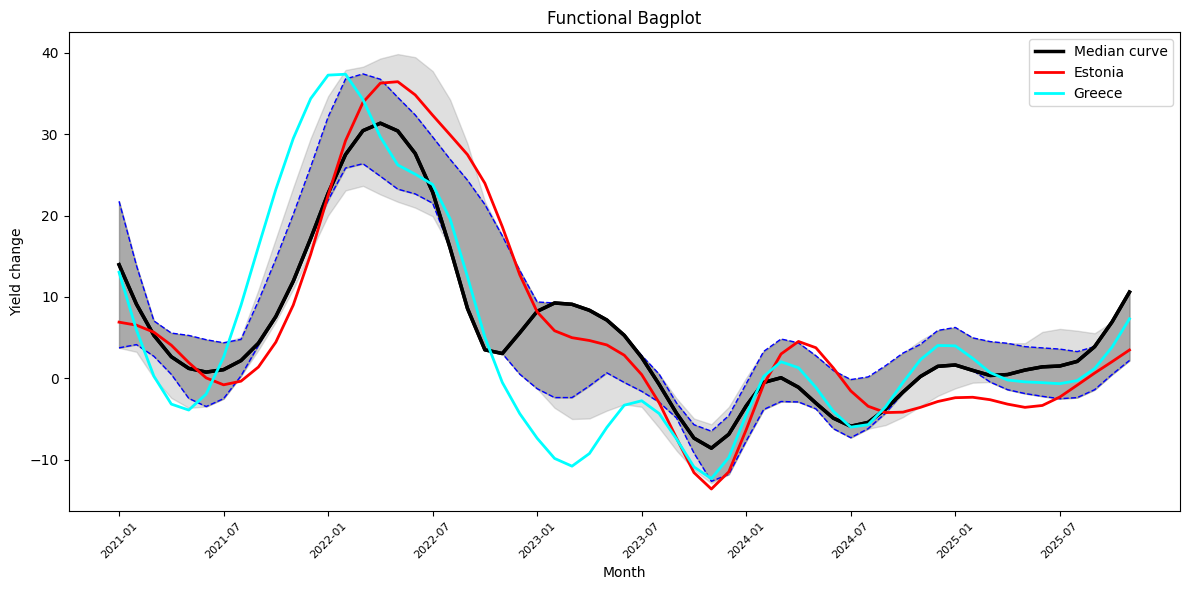

Outliers: ['Estonia', 'Greece']


In [13]:
from scipy import stats
from scipy.spatial import ConvexHull
from matplotlib.path import Path

tick_idx    = np.arange(0, 59, 6)
tick_pos    = tt[tick_idx]
tick_labels = [dates.iloc[i].strftime("%Y-%m") for i in tick_idx]

def tukey_depth_2d(points, n_directions=500):
    n = len(points)
    depths = np.full(n, n)
    for _ in range(n_directions):
        angle  = np.random.uniform(0, np.pi)
        v      = np.array([np.cos(angle), np.sin(angle)])
        proj   = points @ v
        ranks  = stats.rankdata(proj)
        depths = np.minimum(depths, np.minimum(ranks, n - ranks + 1))
    return depths / n

proj2d     = scores_flipped[:, :2]
td         = tukey_depth_2d(proj2d)
median_idx = np.argmax(td)
bag_idx    = np.where(td >= np.median(td))[0]
median_pt  = proj2d[median_idx]
bag_pts    = proj2d[bag_idx]


FENCE_MULT   = 2.0
fence_pts    = median_pt + FENCE_MULT * (bag_pts - median_pt)
hull         = ConvexHull(fence_pts)
hull_path    = Path(fence_pts[hull.vertices])
outlier_mask = ~hull_path.contains_points(proj2d)
outlier_idx  = np.where(outlier_mask)[0]

fence_idx    = np.where(~outlier_mask)[0]
bag_curves   = yields_matrix[:, bag_idx]
fence_curves = yields_matrix[:, fence_idx]
median_curve = yields_matrix[:, median_idx]

bag_lo,   bag_hi   = bag_curves.min(axis=1),   bag_curves.max(axis=1)
fence_lo, fence_hi = fence_curves.min(axis=1), fence_curves.max(axis=1)


fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(tt, fence_lo, fence_hi, color='grey', alpha=0.25, zorder=1)
ax.fill_between(tt, bag_lo,   bag_hi,   color='grey', alpha=0.55, zorder=2)
ax.plot(tt, bag_lo,       color='blue',  lw=1,   linestyle='--', zorder=3)
ax.plot(tt, bag_hi,       color='blue',  lw=1,   linestyle='--', zorder=3)
ax.plot(tt, median_curve, color='black', lw=2.5, zorder=4)


outlier_colors  = ['red', 'cyan', 'orange', 'magenta', 'lime']
outlier_handles = []
outlier_handles = [plt.Line2D([0], [0], color='black', lw=2.5, label=f'Median curve')]

for k, j in enumerate(outlier_idx):
    col = outlier_colors[k % len(outlier_colors)]
    ax.plot(tt, yields_matrix[:, j], color=col, lw=2, zorder=5)
    outlier_handles.append(plt.Line2D([0], [0], color=col, lw=2, label=countries[j]))

ax.plot(tt, median_curve, color='black', lw=2.5, zorder=4)
ax.legend(handles=outlier_handles, frameon=True, loc='upper right')

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Yield change")
ax.set_title("Functional Bagplot")
ax.legend(handles=outlier_handles, frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

print("Outliers:", [countries[j] for j in outlier_idx])


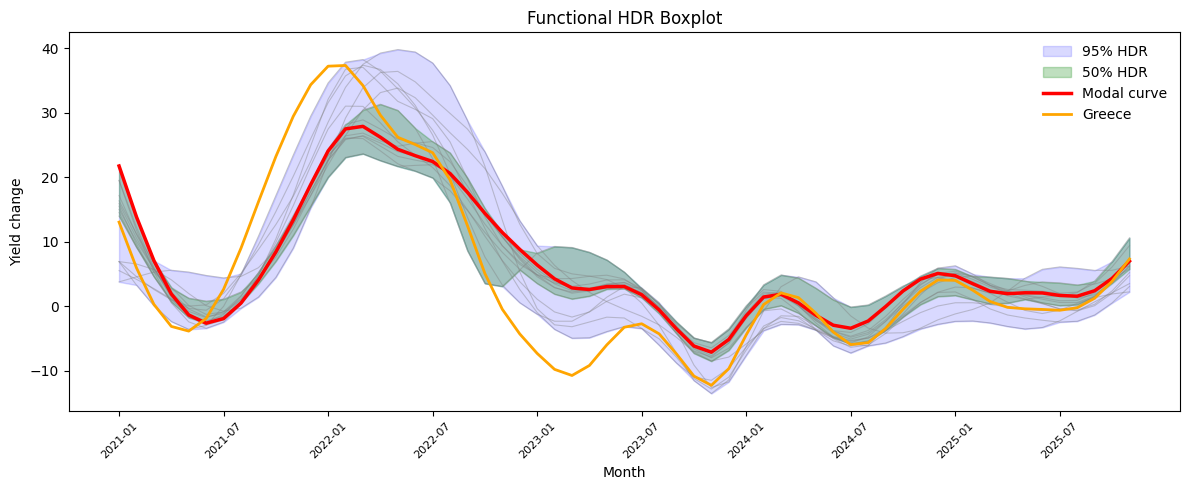

Outliers: ['Greece']


In [14]:
from scipy.stats import gaussian_kde

kde      = gaussian_kde(scores_flipped[:, :2].T)
density  = kde(scores_flipped[:, :2].T)

hdr50_idx  = density >= np.percentile(density, 50)
hdr95_idx  = density >= np.percentile(density, 5)
modal_idx  = np.argmax(density)

# outliers = below 95% HDR
outlier_mask = ~hdr95_idx
outlier_idx  = np.where(outlier_mask)[0]

fig, ax = plt.subplots(figsize=(12, 5))

for j in range(yields_matrix.shape[1]):
    if j not in outlier_idx:
        ax.plot(tt, yields_matrix[:, j], color='grey', lw=0.8, alpha=0.4)

c50 = yields_matrix[:, hdr50_idx]
c95 = yields_matrix[:, hdr95_idx]
ax.fill_between(tt, c95.min(axis=1), c95.max(axis=1), alpha=0.15, color='blue',  label='95% HDR')
ax.fill_between(tt, c50.min(axis=1), c50.max(axis=1), alpha=0.25, color='green', label='50% HDR')
ax.plot(tt, yields_matrix[:, modal_idx], color='red', lw=2.5, label=f'Modal curve')

outlier_colors  = ['orange','lime', 'cyan', 'magenta']
outlier_handles = []
for k, j in enumerate(outlier_idx):
    col = outlier_colors[k % len(outlier_colors)]
    ax.plot(tt, yields_matrix[:, j], color=col, lw=2, zorder=5)
    outlier_handles.append(plt.Line2D([0], [0], color=col, lw=2, label=countries[j]))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + outlier_handles, frameon=False)

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("Yield change")
ax.set_title("Functional HDR Boxplot")
plt.tight_layout()
plt.show()

print("Outliers:", [countries[j] for j in outlier_idx])

## 7.1 Outliers - nesigauna

In [ ]:
sitas kodas "neišverstas"


foutliers(yld, method = "robMah")
foutliers(yld, method = "lrt")
foutliers(yld, method = "depth.trim")
foutliers(yld, method = "depth.pond")
foutliers(yld, method = "HUoutliers")

SyntaxError: invalid syntax (2077099712.py, line 1)

## 8. Hypothesis Testing — Two-Sample Functions

In [15]:
import numpy as np
from scipy import stats

# trace function 
def trace(A):
    return np.sum(np.diag(A))

# pointwise two-sample Z test 
def Ztwosample(x, y, t_seq, alpha=0.05, plot=True):
    """
    x, y : np.ndarray of shape (n_timepoints, n_curves)
    t_seq: np.ndarray of time points
    """
    n = x.shape[1]
    m = y.shape[1]
    k = len(t_seq)

    # mean functions
    mu_x = x.mean(axis=1, keepdims=True)   
    mu_y = y.mean(axis=1, keepdims=True)
    delta_t = mu_x - mu_y                  

    # centered data
    z_x = x - mu_x
    z_y = y - mu_y
    z_t = np.hstack([z_x, z_y])          

    # pooled variance estimator
    pooled_df = n + m - 2
    if pooled_df > k:
        Sigma = z_t.T @ z_t / pooled_df    
    else:
        Sigma = z_t @ z_t.T / pooled_df    

    gamma_t = np.diag(Sigma)               

    # Z statistic
    Zpointwise = np.sqrt((n * m) / (n + m)) * delta_t.flatten() / np.sqrt(gamma_t)

    # critical value
    crit_val = stats.t.ppf(1 - alpha / 2, df=pooled_df)


    if plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(t_seq, Zpointwise, color='darkred', lw=2, label='Z statistic')
        ax.axhline( crit_val, color='blue', linestyle='--', lw=2, label='Critical values')
        ax.axhline(-crit_val, color='blue', linestyle='--', lw=2)
        ax.axhline(0, color='gray', linestyle=':', lw=1)
        ax.set_xlabel("Time")
        ax.set_ylabel("Z statistic")
        ax.set_title("Pointwise Two-Sample t-Test")
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    return {
        'statistics_pointwise': Zpointwise,
        'critical_value': crit_val,
        'alpha': alpha,
        'time_seq': t_seq
    }


#  bootstrap permutation test 
def bootstrap_FDA(core_mat, per_mat, t_seq, B=1000):
    """
    core_mat, per_mat : np.ndarray of shape (n_timepoints, n_curves)
    """
    all_mat  = np.hstack([core_mat, per_mat]) 
    n_core   = core_mat.shape[1]
    n_total  = all_mat.shape[1]
    T_boot   = np.zeros(B)

    for b in range(B):
        perm      = np.random.permutation(n_total)
        mat_b     = all_mat[:, perm]
        core_b    = mat_b[:, :n_core]
        per_b     = mat_b[:, n_core:]
        res_b = Ztwosample(core_b, per_b, t_seq, plot=False)
        T_boot[b] = np.max(np.abs(res_b['statistics_pointwise']))

    return T_boot


# F-statistic two-sample test 
def F_stat_twosample(x, y, t_seq, alpha=0.05, method=1, replications=100):
    n = x.shape[1]
    m = y.shape[1]
    k = len(t_seq)

    mu_x    = x.mean(axis=1, keepdims=True)
    mu_y    = y.mean(axis=1, keepdims=True)
    delta_t = mu_x - mu_y

    z_x = x - mu_x
    z_y = y - mu_y
    z_t = np.hstack([z_x, z_y])

    cn = (n * m) / (n + m)

    if n > k or m > k:
        Sigma = z_t.T @ z_t / (n - 2)
    else:
        Sigma = z_t @ z_t.T / (n - 2)

    A     = trace(Sigma)
    B_tr  = trace(Sigma ** 2)       
    Fstat = float(cn * delta_t.T @ delta_t / A)

    if method == 1:
        kappa  = A ** 2 / B_tr
        pvalue = 1 - stats.f.cdf(Fstat, kappa, (n - 2) * kappa)
        params = {'df1': kappa, 'df2': (n - 2) * kappa}

    elif method == 2:
        bt_Fstat = np.zeros(replications)
        for i in range(replications):
            rep1   = np.random.choice(n, n, replace=True)
            rep2   = np.random.choice(m, m, replace=True)
            x_star = x[:, rep1]
            y_star = y[:, rep2]
            mu_xs  = x_star.mean(axis=1, keepdims=True)
            mu_ys  = y_star.mean(axis=1, keepdims=True)

            delta_star = mu_xs - mu_ys
            z_xs   = x_star - mu_xs
            z_ys   = y_star - mu_ys
            z_star = np.hstack([z_xs, z_ys])

            if n > k or m > k:
                bt_Sigma = z_star.T @ z_star / (n - 2)
            else:
                bt_Sigma = z_star @ z_star.T / (n - 2)

            bt_mu       = delta_star.mean(axis=1, keepdims=True) - delta_t
            bt_Fstat[i] = float(cn * bt_mu.T @ bt_mu / trace(bt_Sigma))

        pvalue = np.mean(bt_Fstat >= Fstat)
        params = {'bt_Fstat': bt_Fstat}

    return {'statistics': Fstat, 'pvalue': pvalue, 'params': params}


#  L2-norm two-sample test 
def L2_stat_twosample(x, y, t_seq, alpha=0.05, method=1, replications=100):
    n = x.shape[1]
    m = y.shape[1]
    k = len(t_seq)

    mu_x    = x.mean(axis=1, keepdims=True)
    mu_y    = y.mean(axis=1, keepdims=True)
    delta_t = mu_x - mu_y

    z_x = x - mu_x
    z_y = y - mu_y
    z_t = np.hstack([z_x, z_y])

    cn = (n * m) / (n + m)

    if n > k or m > k:
        Sigma = z_t.T @ z_t / (n - 2)
    else:
        Sigma = z_t @ z_t.T / (n - 2)

    A      = trace(Sigma)
    B_tr   = trace(Sigma ** 2)        
    L2stat = float(cn * delta_t.T @ delta_t)

    if method == 1:
        alp    = B_tr / A
        df     = A ** 2 / B_tr
        pvalue = 1 - stats.chi2.cdf(L2stat / alp, df)
        params = {'alpha': alp, 'df': df}

    elif method == 2:
        bt_L2stat = np.zeros(replications)
        for i in range(replications):
            rep1   = np.random.choice(n, n, replace=True)
            rep2   = np.random.choice(m, m, replace=True)
            x_star = x[:, rep1]
            y_star = y[:, rep2]
            mu_xs  = x_star.mean(axis=1, keepdims=True)
            mu_ys  = y_star.mean(axis=1, keepdims=True)

            delta_star = mu_xs - mu_ys
            bt_mu      = delta_star.mean(axis=1, keepdims=True) - delta_t

            bt_L2stat[i] = float(cn * bt_mu.T @ bt_mu)

        pvalue = np.mean(bt_L2stat >= L2stat)
        params = {'boot_stat': bt_L2stat}

    return {'statistics': L2stat, 'pvalue': pvalue, 'params': params}

## 9. Hypothesis 1 — Core vs Peripheral Countries

**H₀:** No difference in mean yield functions between core and peripheral countries  
**H₁:** Mean yield curves of the two groups differ


In [16]:
import numpy as np
from skfda import FDataBasis
from skfda.representation.basis import BSpline

core_names = ["Germany", "France", "Netherlands", "Austria", "Belgium"]
per_names  = ["Italy", "Greece", "Portugal", "Cyprus", "Ireland",
              "Latvia", "Lithuania", "Malta", "Slovakia",
              "Estonia", "Finland"]

core_idx = [i for i, c in enumerate(countries) if c in core_names]
per_idx  = [i for i, c in enumerate(countries) if c in per_names]

t_seq      = np.linspace(1, 59, 300)
yields_eval = yields_fd(t_seq).squeeze().T

core_mat = yields_eval[:, core_idx]  
per_mat  = yields_eval[:, per_idx]  


In [17]:
# f stat two sample test
result2 = F_stat_twosample(core_mat, per_mat, t_seq, method=1, replications=5000)

print(f"F statistic : {result2['statistics']:.4f}")
print(f"P-value     : {result2['pvalue']:.4f}")

if result2['pvalue'] < 0.05:
    print("Reject H0: Core and peripheral yield functions differ")
else:
    print("Fail to reject H0")

F statistic : 0.6729
P-value     : 0.9990
Fail to reject H0


C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\1459246156.py:110: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Fstat = float(cn * delta_t.T @ delta_t / A)


In [18]:
# L2 test — analytical (chi-sq) and bootstrap
result_L2_m1 = L2_stat_twosample(core_mat, per_mat, t_seq, method=1, replications=1000)
result_L2_m2 = L2_stat_twosample(core_mat, per_mat, t_seq, method=2, replications=1000)

print(f"L2 chi-sq  : stat={result_L2_m1['statistics']:.4f}  p={result_L2_m1['pvalue']:.4f}")
print(f"L2 bootstrap: stat={result_L2_m2['statistics']:.4f}  p={result_L2_m2['pvalue']:.4f}")

L2 chi-sq  : stat=9708.1543  p=0.9997
L2 bootstrap: stat=9708.1543  p=0.0000


C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\1459246156.py:169: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L2stat = float(cn * delta_t.T @ delta_t)
C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\1459246156.py:190: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_L2stat[i] = float(cn * bt_mu.T @ bt_mu)


## 10. Hypothesis 2 — High vs Lower Credit Rating Countries

**H₀:** No difference in mean yield functions between AAA/AA and A-and-below countries  
**H₁:** Mean yield curves of the two groups differ


In [19]:
# High grade: AAA + AA
high_names  = ["Germany", "Netherlands", "Finland",
               "Austria", "Belgium", "Ireland"]
# Lower grade: A and below
lower_names = ["France", "Portugal", "Slovakia", "Estonia",
               "Latvia", "Lithuania", "Malta", "Cyprus",
               "Italy", "Greece"]

high_idx  = [i for i, c in enumerate(countries) if c in high_names]
lower_idx = [i for i, c in enumerate(countries) if c in lower_names]

t_seq       = np.linspace(1, 59, 300)
yields_eval = yields_fd(t_seq).squeeze().T 

high_mat  = yields_eval[:, high_idx]
lower_mat = yields_eval[:, lower_idx]

 

In [20]:
# F stat test
result2 = F_stat_twosample(high_mat, lower_mat, t_seq, method=1, replications=1000)

print(f"F statistic : {result2['statistics']:.4f}")
print(f"P-value     : {result2['pvalue']:.4f}")

if result2['pvalue'] < 0.05:
    print("Reject H0: High and low credit rating country yield functions differ")
else:
    print("Fail to reject H0")


F statistic : 1.0641
P-value     : 0.2909
Fail to reject H0


C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\1459246156.py:110: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Fstat = float(cn * delta_t.T @ delta_t / A)


In [21]:
# L2 test — analytical (chi-sq) and bootstrap
r_L2_1b = L2_stat_twosample(high_mat, lower_mat, t_seq, method=1, replications=1000)
r_L2_2b = L2_stat_twosample(high_mat, lower_mat, t_seq, method=2, replications=1000)
print(f"L2 chi-sq  : stat={r_L2_1b['statistics']:.4f}  p={r_L2_1b['pvalue']:.4f}")
print(f"L2 bootstrap: stat={r_L2_2b['statistics']:.4f}  p={r_L2_2b['pvalue']:.4f}")

L2 chi-sq  : stat=11134.5318  p=0.2652
L2 bootstrap: stat=11134.5318  p=0.0000


C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\1459246156.py:169: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L2stat = float(cn * delta_t.T @ delta_t)
C:\Users\Namai\AppData\Local\Temp\ipykernel_18492\1459246156.py:190: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_L2stat[i] = float(cn * bt_mu.T @ bt_mu)


## 11. Hypothesis 3 — Change-Point Analysis

**H₀:** The mean yield change function is stable over time  
**H₁:** At least one structural break exists in the functional mean


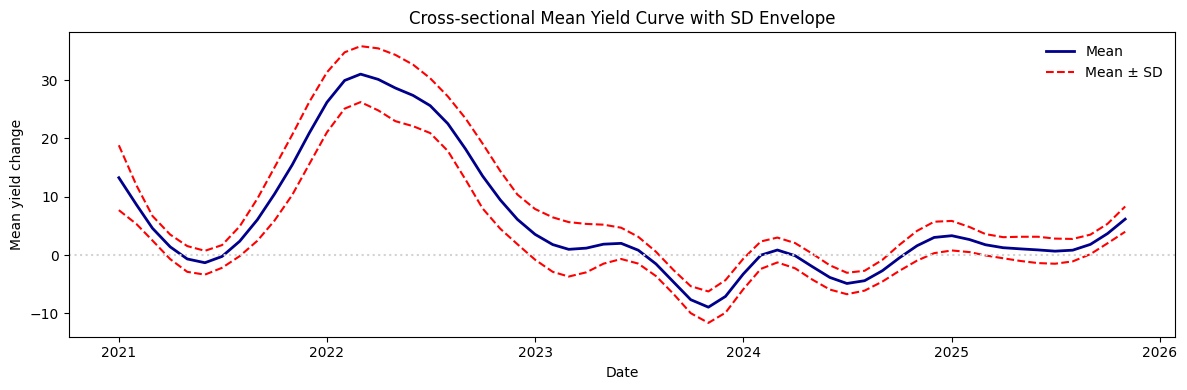

In [22]:
import ruptures as rpt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.regression.linear_model import OLS

t_seq_monthly      = np.linspace(1, 59, 59)
yields_mat_monthly = np.array([
    np.interp(t_seq_monthly, tt, yields_matrix[:, j])
    for j in range(yields_matrix.shape[1])
]).T

mean_curve = yields_mat_monthly.mean(axis=1)
sd_curve   = yields_mat_monthly.std(axis=1, ddof=1)

months = pd.date_range("2021-01-01", "2025-11-01", freq="MS")

def idx_to_date(idx_arr, months):
    """Convert 1-based indices to YYYY-MM strings."""
    return [months[int(i)-1].strftime("%Y-%m") for i in idx_arr if 1 <= int(i) <= len(months)]

# Plot mean ± SD
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(months, mean_curve, color="darkblue", lw=2, label="Mean")
ax.plot(months, mean_curve + sd_curve, color="red", ls="--", lw=1.5, label="Mean ± SD")
ax.plot(months, mean_curve - sd_curve, color="red", ls="--", lw=1.5)
ax.axhline(0, color="lightgrey", ls=":")
ax.set_xlabel("Date"); ax.set_ylabel("Mean yield change")
ax.set_title("Cross-sectional Mean Yield Curve with SD Envelope")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

In [23]:
import numpy as np
import ruptures as rpt

vec = mean_curve.copy()
n   = len(vec)

def rss_cost(signal):
    cumsum  = np.concatenate([[0], np.cumsum(signal)])
    cumsum2 = np.concatenate([[0], np.cumsum(signal**2)])
    def cost(start, end):
        length = end - start
        if length < 2:
            return 0
        s  = cumsum[end]  - cumsum[start]
        s2 = cumsum2[end] - cumsum2[start]
        rss = s2 - s**2 / length
        return max(rss, 0)
    return cost

cost_fn = rss_cost(vec)


rss_total = np.inf
amoc_idx  = [n // 2]
for t in range(2, n - 1):
    c = cost_fn(0, t) + cost_fn(t, n)
    if c < rss_total:
        rss_total = c
        amoc_idx  = [t]

print(f"AMOC index: {amoc_idx}  →  {idx_to_date(amoc_idx, months)}")

AMOC index: [23]  →  ['2022-11']


# Nuo čia žemyn nebesutampa rezultatai

In [ ]:
Kodas kuriam reikia vertimo: 

# --- PELT with multiple penalties ---
# Default penalty often overfits smooth functional data — compare all options
cpt_pelt_default <- cpt.mean(vec, method = "PELT")
cpt_pelt_bic     <- cpt.mean(vec, penalty = "BIC",          method = "PELT")
cpt_pelt_mbic    <- cpt.mean(vec, penalty = "MBIC",         method = "PELT")
cpt_pelt_aic     <- cpt.mean(vec, penalty = "AIC",          method = "PELT")
cpt_pelt_hq      <- cpt.mean(vec, penalty = "Hannan-Quinn", method = "PELT")
# Manual stronger penalty: 3*log(n) — recommended for smooth series
cpt_pelt_manual  <- cpt.mean(vec, penalty  = "Manual",
                             pen.value = 3 * log(length(vec)),
                             method    = "PELT")

cat("=== PELT penalty comparison ===\n")
cat("Default:       ", ncpts(cpt_pelt_default), "breaks:",
    idx_to_date(cpts(cpt_pelt_default), months), "\n")
cat("AIC:           ", ncpts(cpt_pelt_aic),     "breaks:",
    idx_to_date(cpts(cpt_pelt_aic),     months), "\n")
cat("BIC:           ", ncpts(cpt_pelt_bic),     "breaks:",
    idx_to_date(cpts(cpt_pelt_bic),     months), "\n")
cat("MBIC:          ", ncpts(cpt_pelt_mbic),    "breaks:",
    idx_to_date(cpts(cpt_pelt_mbic),    months), "\n")
cat("Hannan-Quinn:  ", ncpts(cpt_pelt_hq),      "breaks:",
    idx_to_date(cpts(cpt_pelt_hq),      months), "\n")
cat("Manual 3log(n):", ncpts(cpt_pelt_manual),  "breaks:",
    idx_to_date(cpts(cpt_pelt_manual),  months), "\n\n")

# Choose best PELT — prefer BIC or MBIC for small n
# Use the one with smaller number of breaks
cpt_pelt_best <- cpt_pelt_mbic

# SegNeigh with BIC
cpt_segneigh <- cpt.mean(vec, penalty = "BIC", method = "SegNeigh")
cat("SegNeigh BIC breaks:", idx_to_date(cpts(cpt_segneigh), months), "\n\n")

# BinSeg
cpt_binseg <- cpt.mean(vec, method = "BinSeg")
cat("BinSeg breaks:      ", idx_to_date(cpts(cpt_binseg), months), "\n\n")


#changepoint panel plot 
par(mfrow = c(2, 2))
plot(cpt_amoc,      main = "AMOC",         xlab = "Month index", ylab = "Mean yield")
plot(cpt_pelt_best, main = "PELT (BIC)",   xlab = "Month index", ylab = "Mean yield")
plot(cpt_segneigh,  main = "SegNeigh BIC", xlab = "Month index", ylab = "Mean yield")
plot(cpt_binseg,    main = "BinSeg",       xlab = "Month index", ylab = "Mean yield")
par(mfrow = c(1, 1))


#ecp package 
# e.divisive: non-parametric, energy-based, multiple change points
output_div <- e.divisive(matrix(vec), R = 499, alpha = 2)
cat("e.divisive detected:", output_div$k.hat, "change points\n")
cat("e.divisive dates:   ",
    idx_to_date(output_div$estimates, months), "\n\n")

# e.agglo: agglomerative alternative
output_agg <- e.agglo(X = matrix(vec), alpha = 1)
cat("e.agglo dates:      ",
    idx_to_date(output_agg$estimates, months), "\n\n")

# ecp panel plot
par(mfrow = c(1, 2))

plot(months, vec, type = "l", lwd = 2, col = "darkblue",
     xlab = "Date", ylab = "Mean yield change",
     main = "e.divisive")
abline(v = months[output_div$estimates[
  output_div$estimates >= 1 & output_div$estimates <= 63]],
  col = "red", lty = 2, lwd = 2)

plot(months, vec, type = "l", lwd = 2, col = "darkblue",
     xlab = "Date", ylab = "Mean yield change",
     main = "e.agglo")
abline(v = months[output_agg$estimates[
  output_agg$estimates >= 1 & output_agg$estimates <= 63]],
  col = "orange", lty = 2, lwd = 2)

par(mfrow = c(1, 1))


#EnvCpt model selection
models_yields <- envcpt(vec,
                        models = c("mean",      "meanar1",     "meanar2",
                                   "meanar1cpt","meanar2cpt",
                                   "trend",     "trendcpt",
                                   "trendar1",  "trendar2",
                                   "trendar1cpt","trendar2cpt"))

# Diagnostic plots
plot(models_yields, type = "fit")
plot(models_yields, type = "aic")
plot(models_yields, type = "bic")

best_aic <- names(which.min(AIC(models_yields)))
best_bic <- names(which.min(BIC(models_yields)))
cat("EnvCpt best model (AIC):", best_aic, "\n")
cat("EnvCpt best model (BIC):", best_bic, "\n\n")

# Extract change points from best BIC model
# The @cpts slot contains break indices
best_model_obj <- models_yields[[best_bic]]
envcpt_cpts <- tryCatch(
  best_model_obj@cpts,
  error = function(e) {
    cat("Note: best BIC model has no change points\n")
    integer(0)
  }
)
# Remove terminal index (EnvCpt always includes n as last cpt)
envcpt_cpts <- envcpt_cpts[envcpt_cpts < length(vec)]

cat("EnvCpt break dates (", best_bic, "):",
    idx_to_date(envcpt_cpts, months), "\n\n")


#Consensus: which breaks are most credible
#A break found by 2+ methods = strong evidence 
# Collect all break indices from methods with <= 6 breaks
collect_breaks <- function(idx_vec, max_breaks = 6) {
  idx_vec <- idx_vec[idx_vec >= 1 & idx_vec <= 63]
  if (length(idx_vec) <= max_breaks) idx_vec else integer(0)
}

agg_breaks <- output_agg$estimates[
  output_agg$estimates > 1 & output_agg$estimates < length(vec)]

all_breaks <- c(
  collect_breaks(cpts(cpt_amoc)),
  collect_breaks(cpts(cpt_pelt_best)),
  collect_breaks(cpts(cpt_segneigh)),
  collect_breaks(cpts(cpt_binseg)),
  collect_breaks(output_div$estimates),
  collect_breaks(agg_breaks),         
  collect_breaks(envcpt_cpts)
)

# Cluster breaks within a 3-month window
cluster_breaks <- function(breaks, window = 3) {
  if (length(breaks) == 0) return(integer(0))
  breaks  <- sort(breaks)
  cluster <- rep(0, length(breaks))
  cid     <- 1
  cluster[1] <- cid
  for (i in 2:length(breaks)) {
    if (breaks[i] - breaks[i-1] <= window) {
      cluster[i] <- cid
    } else {
      cid <- cid + 1
      cluster[i] <- cid
    }
  }
  # Representative = median index of each cluster
  sapply(unique(cluster), function(c) round(median(breaks[cluster == c])))
}

break_freq   <- table(all_breaks)
credible_idx <- as.integer(names(break_freq[break_freq >= 2]))
credible_idx <- cluster_breaks(credible_idx, window = 3)

cat("=== CONSENSUS BREAK POINTS ===\n")
cat("(Detected by 2+ methods)\n\n")
if (length(credible_idx) == 0) {
  cat("No consensus break points found\n")
} else {
  for (i in seq_along(credible_idx)) {
    cat(sprintf("Break %d: index %d → %s\n",
                i, credible_idx[i],
                idx_to_date(credible_idx[i], months)))
  }
}


#summary plot 
method_colors <- c("red", "darkgreen", "purple", "steelblue",
                   "orange", "hotpink", "brown")
method_ltys   <- c(2, 3, 4, 5, 6, 2, 3)
method_names  <- c("AMOC", "PELT BIC", "SegNeigh", "BinSeg",
                   "e.divisive", "e.agglo", "EnvCpt BIC")

method_breaks <- list(
  collect_breaks(cpts(cpt_amoc)),
  collect_breaks(cpts(cpt_pelt_best)),
  collect_breaks(cpts(cpt_segneigh)),
  collect_breaks(cpts(cpt_binseg)),
  collect_breaks(output_div$estimates),
  collect_breaks(agg_breaks),         
  collect_breaks(envcpt_cpts)
)

plot(months, vec,
     type = "l", lwd = 2.5, col = "darkblue",
     xlab = "Date",
     ylab = "Cross-sectional mean yield change",
     main = "Change Point Detection — All Methods",
     las  = 2)
abline(h = 0, col = "gray70", lty = 3)

# Plot each method's breaks
for (m in seq_along(method_breaks)) {
  breaks_m <- method_breaks[[m]]
  if (length(breaks_m) > 0) {
    abline(v   = months[breaks_m],
           col = method_colors[m],
           lty = method_ltys[m],
           lwd = 1.8)
  }
}

# Highlight consensus breaks with shaded band
if (length(credible_idx) > 0) {
  for (ci in credible_idx) {
    rect(months[max(1, ci-1)], par("usr")[3],
         months[min(63, ci+1)], par("usr")[4],
         col = adjustcolor("gold", alpha.f = 0.25),
         border = NA)
  }
}

legend("topright",
       legend = c("Mean curve", method_names, "Consensus zone"),
       col    = c("darkblue", method_colors, "gold"),
       lty    = c(1, method_ltys, 1),
       lwd    = c(2.5, rep(1.8, 6), 8),
       bty    = "n", cex = 0.75)


# Results summary table  
cat("\n==========================================\n")
cat("   CHANGE POINT ANALYSIS — FINAL RESULTS  \n")
cat("==========================================\n\n")

cat("--- Break points by method ---\n")
cat(sprintf("%-18s %s\n", "Method", "Break dates"))
cat(strrep("-", 50), "\n")
cat(sprintf("%-18s %s\n", "AMOC",
            paste(idx_to_date(cpts(cpt_amoc), months), collapse = ", ")))
cat(sprintf("%-18s %s\n", "PELT (BIC)",
            paste(idx_to_date(cpts(cpt_pelt_best), months), collapse = ", ")))
cat(sprintf("%-18s %s\n", "SegNeigh (BIC)",
            paste(idx_to_date(cpts(cpt_segneigh), months), collapse = ", ")))
cat(sprintf("%-18s %s\n", "BinSeg",
            paste(idx_to_date(cpts(cpt_binseg), months), collapse = ", ")))
cat(sprintf("%-18s %s\n", "e.divisive",
            paste(idx_to_date(
              output_div$estimates[output_div$estimates > 1 &
                                     output_div$estimates < 63],
              months), collapse = ", ")))

cat(sprintf("%-18s %s\n", "e.agglo",           # NEW LINE
            paste(idx_to_date(agg_breaks, months), collapse = ", ")))

cat(sprintf("%-18s %s\n", paste0("EnvCpt (", best_bic, ")"),
            paste(idx_to_date(envcpt_cpts, months), collapse = ", ")))
cat(strrep("-", 50), "\n")
cat(sprintf("%-18s %s\n", "CONSENSUS",
            paste(idx_to_date(credible_idx, months), collapse = ", ")))
cat(strrep("=", 50), "\n\n")

cat("Conclusion: ")
if (length(credible_idx) == 0) {
  cat("No robust evidence against H0.\n")
} else {
  cat("H0 rejected. Structural breaks detected at:\n")
  for (i in seq_along(credible_idx)) {
    cat(sprintf("  Break %d: %s\n", i,
                idx_to_date(credible_idx[i], months)))
  }
}


#final nice plot

plot(months, vec,
     type = "l", lwd = 2.5, col = "darkblue",
     xlab = "Date",
     ylab = "Cross-sectional mean yield change (%)",
     main = "Structural Breaks in Eurozone Mean Yield Curve",
     las  = 2, cex.axis = 0.8)
abline(h = 0, col = "gray70", lty = 3)

# Shade consensus break regions
for (ci in credible_idx) {
  rect(months[max(1, ci-1)], par("usr")[3],
       months[min(63, ci+1)], par("usr")[4],
       col    = adjustcolor("gold", alpha.f = 0.3),
       border = NA)
}

# Add vertical lines at consensus breaks
abline(v   = months[credible_idx],
       col = "darkred", lty = 2, lwd = 2)


legend("topright",
       legend = c("Cross-sectional mean", "Consensus break", "Break region"),
       col    = c("darkblue", "darkred", "gold"),
       lty    = c(1, 2, 1),
       lwd    = c(2.5, 2, 8),
       bty    = "n", cex = 0.85)






#final concensus table
cat("==============================================\n")
cat("  CHANGE POINT ANALYSIS — METHOD COMPARISON  \n")
cat("==============================================\n\n")
cat(sprintf("%-20s %-30s %s\n", "Method", "Break dates", "N breaks"))
cat(strrep("-", 60), "\n")
cat(sprintf("%-20s %-30s %s\n", "AMOC",
            paste(idx_to_date(cpts(cpt_amoc), months), collapse=", "),
            ncpts(cpt_amoc)))
cat(sprintf("%-20s %-30s %s\n", "PELT (BIC)",
            paste(idx_to_date(cpts(cpt_pelt_best), months), collapse=", "),
            ncpts(cpt_pelt_best)))
cat(sprintf("%-20s %-30s %s\n", "SegNeigh (BIC)",
            paste(idx_to_date(cpts(cpt_segneigh), months), collapse=", "),
            ncpts(cpt_segneigh)))
cat(sprintf("%-20s %-30s %s\n", "BinSeg",
            paste(idx_to_date(cpts(cpt_binseg), months), collapse=", "),
            ncpts(cpt_binseg)))
cat(sprintf("%-20s %-30s %s\n", "e.divisive",
            paste(idx_to_date(
              output_div$estimates[output_div$estimates > 1 &
                                     output_div$estimates < 63],
              months), collapse=", "),
            output_div$k.hat))
cat(sprintf("%-20s %-30s %s\n", "e.agglo",
            paste(idx_to_date(agg_breaks, months), collapse=", "),
            length(agg_breaks)))
cat(sprintf("%-20s %-30s %s\n", paste0("EnvCpt(", best_bic,")"),
            paste(idx_to_date(envcpt_cpts, months), collapse=", "),
            length(envcpt_cpts)))
cat(strrep("-", 60), "\n")

#count agreements per consensus break
# Rebuild all per-method break lists with date strings for matching
method_break_dates <- list(
  idx_to_date(collect_breaks(cpts(cpt_amoc)),            months),
  idx_to_date(collect_breaks(cpts(cpt_pelt_best)),       months),
  idx_to_date(collect_breaks(cpts(cpt_segneigh)),        months),
  idx_to_date(collect_breaks(cpts(cpt_binseg)),          months),
  idx_to_date(collect_breaks(output_div$estimates[
    output_div$estimates > 1 &
      output_div$estimates < 63]),                         months),
  idx_to_date(collect_breaks(agg_breaks),                months),
  idx_to_date(collect_breaks(envcpt_cpts),               months)
)
method_labels <- c("AMOC", "PELT", "SegNeigh", "BinSeg",
                   "e.divisive", "e.agglo", "EnvCpt")

# For each consensus break, find which methods detected it
# A method "agrees" if it has a break within 3 months of the consensus index
cat(sprintf("\n%-12s %-14s %-6s %s\n",
            "Break date", "Index", "Agree", "Methods"))
cat(strrep("-", 60), "\n")

for (ci in credible_idx) {
  
  # Which methods have a break within window of ci
  agreeing <- c()
  for (m in seq_along(method_break_dates)) {
    # Convert method date strings back to indices for window comparison
    m_dates <- method_break_dates[[m]]
    if (length(m_dates) == 0) next
    # Find month indices for this method's breaks
    m_idx <- which(format(months, "%Y-%m") %in% m_dates)
    # Check if any are within 3 months of ci
    if (any(abs(m_idx - ci) <= 3)) {
      agreeing <- c(agreeing, method_labels[m])
    }
  }
  
  cat(sprintf("%-12s %-14s %-6s %s\n",
              idx_to_date(ci, months),
              paste0("(t=", ci, ")"),
              paste0(length(agreeing), "/7"),
              paste(agreeing, collapse=", ")))
}

cat(strrep("=", 60), "\n")
cat(sprintf("Threshold: breaks detected by >= 2 methods (window = ±3 months)\n"))
cat(sprintf("Total methods used: 7\n"))
